<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>EDA - Requests por target del POS API de producción</h3>
    <h5>Julio/Agosto 2026</h5>
    <p>Dataset: <code>data/bodegaai-production-pos-api-request-count-per-target-last-30-days-hourly.csv</code></p>
</div>

En esta notebook vamos a realizar un análisis exploratorio de una serie temporal horaria: la cantidad de requests por target del POS API de producción, tomada desde la métrica `RequestCountPerTarget`.

La idea no es entrenar un modelo todavía. Primero necesitamos entender la estructura de la serie: continuidad temporal, patrones diarios, diferencias entre días, valores atípicos y autocorrelación. SIN ESO, modelar sería construir arriba de arena.

#### Preparación del entorno

Las notebooks de ejemplo trabajan de forma exploratoria. Para mantener esa misma dinámica, esta primera celda instala las librerías necesarias si no están disponibles en el kernel actual.

In [14]:
import importlib.util
import subprocess
import sys

required_packages = ["pandas", "numpy", "matplotlib", "seaborn", "statsmodels"]
missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]

if missing_packages:
    print(f"Instalando dependencias faltantes: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Todas las dependencias necesarias están disponibles.")

Todas las dependencias necesarias están disponibles.


#### Importamos los módulos a utilizar

In [15]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Evitamos notación científica en tablas y ejes para que los conteos sean legibles.
pd.options.display.float_format = "{:,.2f}".format
np.set_printoptions(suppress=True)

def format_count_axis(ax):
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.yaxis.get_offset_text().set_visible(False)

#### Leemos los datos

El archivo contiene mediciones horarias. Las columnas `period_start_utc` y `period_end_utc` delimitan cada ventana de medición; la variable principal que vamos a estudiar es `value`, interpretada como requests por target.

In [16]:
DATA_PATH = "../data/bodegaai-production-pos-api-request-count-per-target-last-30-days-hourly.csv"

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,load_balancer,target_group,metric_name,period_start_utc,period_end_utc,value
0,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-18T23:00:00Z,2026-07-19T00:00:00Z,"807,867.00"
1,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19T00:00:00Z,2026-07-19T01:00:00Z,"800,009.00"
2,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19T01:00:00Z,2026-07-19T02:00:00Z,"796,023.00"
3,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19T02:00:00Z,2026-07-19T03:00:00Z,"786,557.50"
4,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19T03:00:00Z,2026-07-19T04:00:00Z,"778,880.00"


#### Inspección inicial

Antes de graficar, revisamos dimensiones, tipos de datos, valores faltantes y cardinalidad. Este paso es básico, pero NO es opcional: evita interpretar mal columnas constantes, fechas como texto o datos incompletos.

In [17]:
print(f"Filas: {df_raw.shape[0]}")
print(f"Columnas: {df_raw.shape[1]}")

display(df_raw.dtypes.to_frame("dtype"))
display(df_raw.isna().sum().to_frame("missing_values"))
display(df_raw.nunique().to_frame("unique_values"))

df_raw.describe(include="all")

Filas: 720
Columnas: 6


,dtype
load_balancer,object
target_group,object
metric_name,object
period_start_utc,object
period_end_utc,object
value,float64


,missing_values
load_balancer,0
target_group,0
metric_name,0
period_start_utc,0
period_end_utc,0
value,0


,unique_values
load_balancer,1
target_group,1
metric_name,1
period_start_utc,720
period_end_utc,720
value,720


,load_balancer,target_group,metric_name,period_start_utc,period_end_utc,value
count,720,720,720,720,720,720.00
unique,1,1,1,720,720,NaN
top,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-18T23:00:00Z,2026-07-19T00:00:00Z,NaN
freq,720,720,720,1,1,NaN
mean,NaN,NaN,NaN,NaN,NaN,"829,949.69"
std,NaN,NaN,NaN,NaN,NaN,"62,410.43"
min,NaN,NaN,NaN,NaN,NaN,"318,307.50"
25%,NaN,NaN,NaN,NaN,NaN,"805,626.12"
50%,NaN,NaN,NaN,NaN,NaN,"835,670.83"
75%,NaN,NaN,NaN,NaN,NaN,"867,032.38"


#### Conversión de fechas y validación temporal

Para trabajar como serie temporal, convertimos los timestamps a fechas UTC, ordenamos la serie y usamos `period_start_utc` como índice temporal. También renombramos `value` a `requests_per_target` para que el análisis sea explícito.

In [18]:
df = df_raw.copy()

df["period_start_utc"] = pd.to_datetime(df["period_start_utc"], utc=True)
df["period_end_utc"] = pd.to_datetime(df["period_end_utc"], utc=True)
df["requests_per_target"] = pd.to_numeric(df["value"], errors="raise")
df["duration"] = df["period_end_utc"] - df["period_start_utc"]

df = df.sort_values("period_start_utc").set_index("period_start_utc")
df.head()

,load_balancer,target_group,metric_name,period_end_utc,value,requests_per_target,duration
period_start_utc,,,,,,,
2026-07-18 23:00:00+00:00,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 00:00:00+00:00,"807,867.00","807,867.00",0 days 01:00:00
2026-07-19 00:00:00+00:00,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 01:00:00+00:00,"800,009.00","800,009.00",0 days 01:00:00
2026-07-19 01:00:00+00:00,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 02:00:00+00:00,"796,023.00","796,023.00",0 days 01:00:00
2026-07-19 02:00:00+00:00,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 03:00:00+00:00,"786,557.50","786,557.50",0 days 01:00:00
2026-07-19 03:00:00+00:00,app/bodegaai-production-alb/31b69d3d76ab5ed1,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 04:00:00+00:00,"778,880.00","778,880.00",0 days 01:00:00


Validamos cuatro cosas importantes:

1. que no existan timestamps duplicados;
2. que no falten horas dentro del período;
3. que cada ventana tenga duración de una hora;
4. que el rango temporal real del dataset quede claro antes de interpretar patrones.

In [19]:
expected_index = pd.date_range(df.index.min(), df.index.max(), freq="h", tz="UTC")
missing_periods = expected_index.difference(df.index)

temporal_validation = pd.Series({
    "inicio": df.index.min(),
    "fin": df.index.max(),
    "filas": len(df),
    "horas_esperadas": len(expected_index),
    "timestamps_duplicados": int(df.index.duplicated().sum()),
    "horas_faltantes": len(missing_periods),
    "duracion_1_hora": bool((df["duration"] == pd.Timedelta(hours=1)).all()),
    "serie_ordenada": bool(df.index.is_monotonic_increasing),
})

display(temporal_validation.to_frame("valor"))

if len(missing_periods) > 0:
    display(missing_periods.to_frame(index=False, name="missing_period_start_utc"))

,valor
inicio,2026-07-18 23:00:00+00:00
fin,2026-08-17 22:00:00+00:00
filas,720
horas_esperadas,720
timestamps_duplicados,0
horas_faltantes,0
duracion_1_hora,True
serie_ordenada,True


#### Preparación de variables temporales

Agregamos variables derivadas para estudiar patrones por hora, día de la semana y fines de semana.

In [20]:
day_name_map = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}
ordered_days = list(day_name_map.values())

eda = df.copy()
eda["date"] = eda.index.date
eda["day"] = eda.index.day
eda["hour"] = eda.index.hour
eda["day_of_week"] = eda.index.dayofweek
eda["day_name"] = eda["day_of_week"].map(day_name_map)
eda["day_name"] = pd.Categorical(eda["day_name"], categories=ordered_days, ordered=True)
eda["is_weekend"] = eda["day_of_week"].isin([5, 6])

eda[["target_group", "metric_name", "period_end_utc", "requests_per_target", "day_name", "hour", "is_weekend"]].head()

,target_group,metric_name,period_end_utc,requests_per_target,day_name,hour,is_weekend
period_start_utc,,,,,,,
2026-07-18 23:00:00+00:00,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 00:00:00+00:00,"807,867.00",Sábado,23,True
2026-07-19 00:00:00+00:00,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 01:00:00+00:00,"800,009.00",Domingo,0,True
2026-07-19 01:00:00+00:00,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 02:00:00+00:00,"796,023.00",Domingo,1,True
2026-07-19 02:00:00+00:00,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 03:00:00+00:00,"786,557.50",Domingo,2,True
2026-07-19 03:00:00+00:00,targetgroup/bodegaai-production-pos-api/cc856a...,RequestCountPerTarget,2026-07-19 04:00:00+00:00,"778,880.00",Domingo,3,True


#### Resumen estadístico de requests por target

Miramos primero la distribución general. Esto nos da una escala de referencia para interpretar los gráficos posteriores.

In [21]:
requests_summary = eda["requests_per_target"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(requests_summary.to_frame("requests_per_target"))

,requests_per_target
count,720.00
mean,"829,949.69"
std,"62,410.43"
min,"318,307.50"
1%,"567,073.25"
5%,"756,824.70"
25%,"805,626.12"
50%,"835,670.83"
75%,"867,032.38"
95%,"907,583.18"


#### Serie horaria completa

Este gráfico muestra la evolución de requests por target hora a hora. Buscamos nivel, tendencia, ciclos diarios y cambios bruscos.

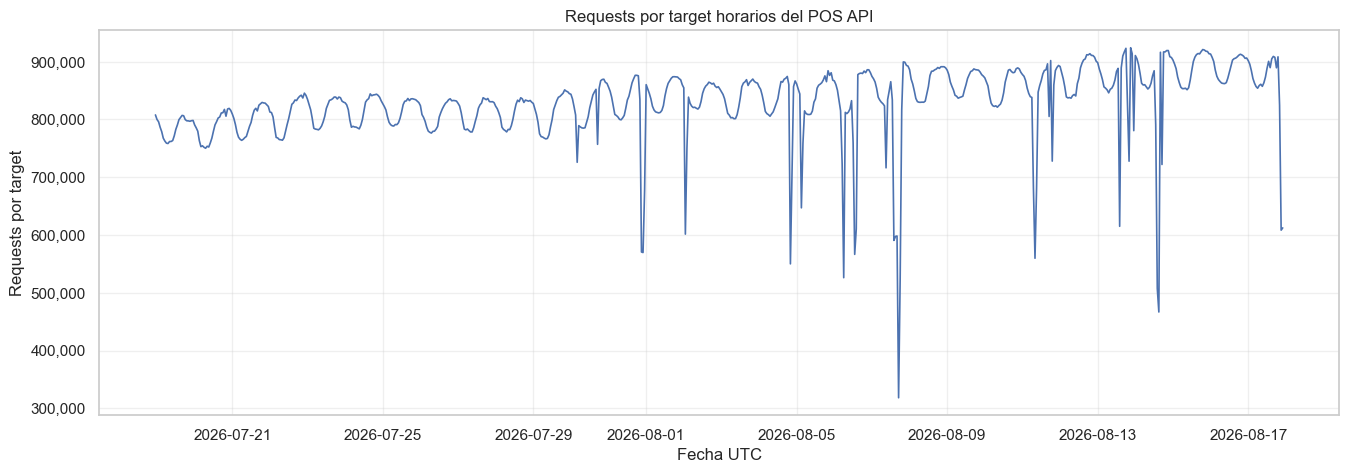

In [22]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(eda.index, eda["requests_per_target"], linewidth=1.2)
ax.set_title("Requests por target horarios del POS API")
ax.set_xlabel("Fecha UTC")
ax.set_ylabel("Requests por target")
format_count_axis(ax)
ax.grid(True, alpha=0.3)
plt.show()

#### Agregación diaria

La serie original es horaria, pero una agregación diaria ayuda a ver diferencias entre días sin tanto ruido intradía. Como la métrica ya está normalizada por target, usamos suma diaria para volumen acumulado y promedio diario para nivel típico horario.

,total,mean
count,31.00,31.00
mean,"19,276,250.93","829,301.85"
std,"3,497,733.79","29,659.25"
min,"807,867.00","781,017.05"
25%,"19,416,512.31","809,021.35"
50%,"19,684,762.25","821,041.75"
75%,"20,282,530.22","851,096.70"
max,"21,393,625.50","891,401.06"


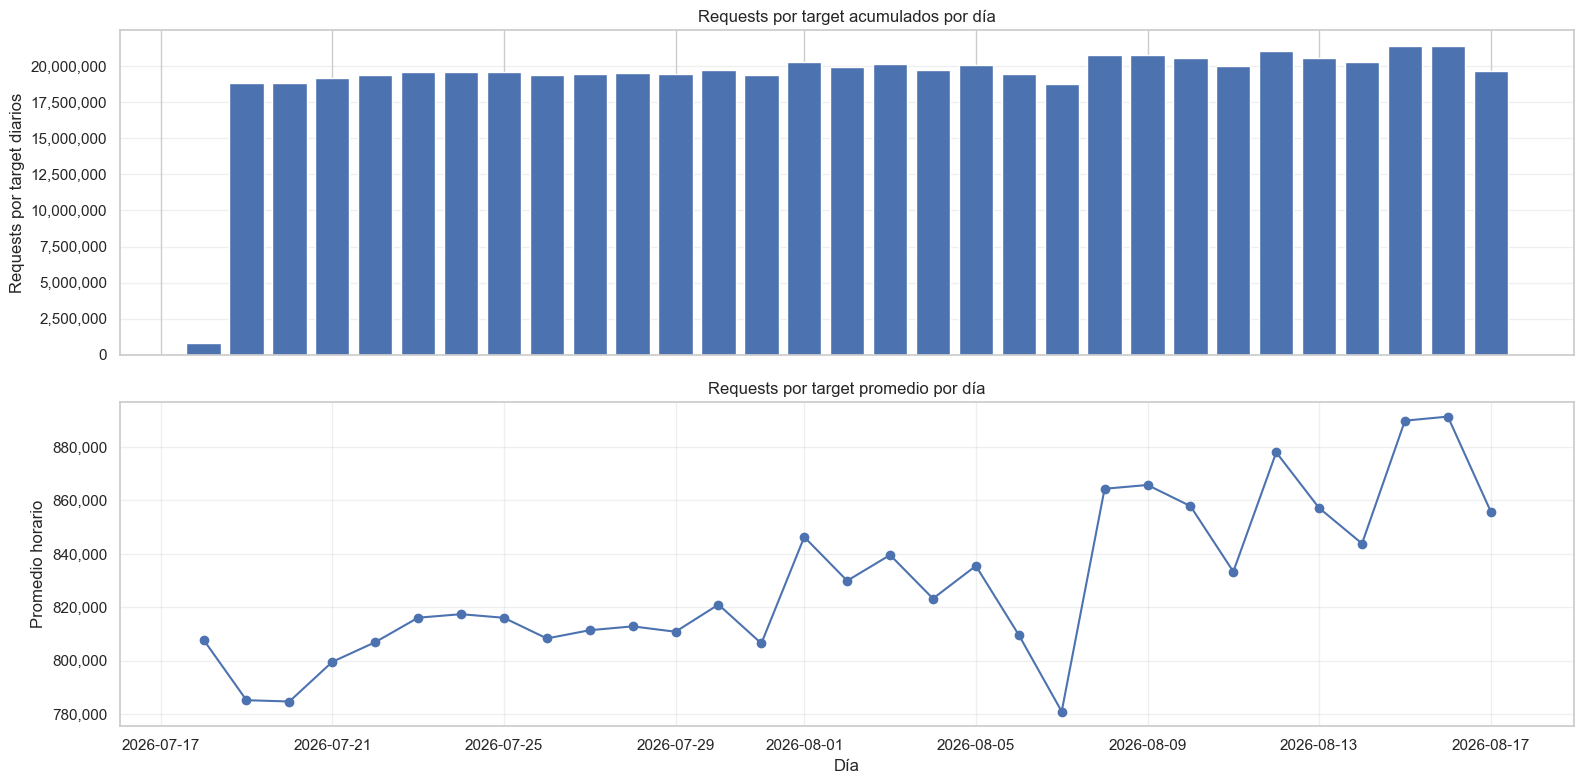

In [23]:
daily_requests = eda["requests_per_target"].resample("D").agg(total="sum", mean="mean")

display(daily_requests.describe())

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].bar(daily_requests.index, daily_requests["total"])
axes[0].set_title("Requests por target acumulados por día")
axes[0].set_ylabel("Requests por target diarios")
format_count_axis(axes[0])
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].plot(daily_requests.index, daily_requests["mean"], marker="o")
axes[1].set_title("Requests por target promedio por día")
axes[1].set_xlabel("Día")
axes[1].set_ylabel("Promedio horario")
format_count_axis(axes[1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Patrón por hora del día

Si hay estacionalidad diaria, deberíamos ver horas con mayor y menor carga promedio. Esta vista resume el comportamiento típico de cada hora.

,mean,median,p25,p75,min,max
hour,,,,,,
0,"855,616.17","856,304.50","827,797.75","883,401.75","790,619.50","913,271.00"
1,"840,548.29","850,540.75","819,639.25","873,665.25","601,571.33","907,485.00"
2,"837,047.02","840,159.50","811,856.62","864,821.88","750,151.00","900,287.50"
3,"821,149.51","826,347.75","797,564.00","854,262.12","647,085.30","885,354.50"
4,"810,024.46","812,289.25","783,729.75","838,904.12","725,869.00","874,736.00"
5,"807,425.39","808,828.25","782,214.62","836,359.88","722,906.75","869,129.00"
6,"798,880.91","806,269.50","781,426.88","835,885.12","526,169.37","865,809.50"
7,"802,074.06","804,467.25","779,029.12","829,118.38","681,447.67","863,048.50"
8,"798,584.98","804,899.75","780,313.00","828,393.75","559,727.00","862,329.50"


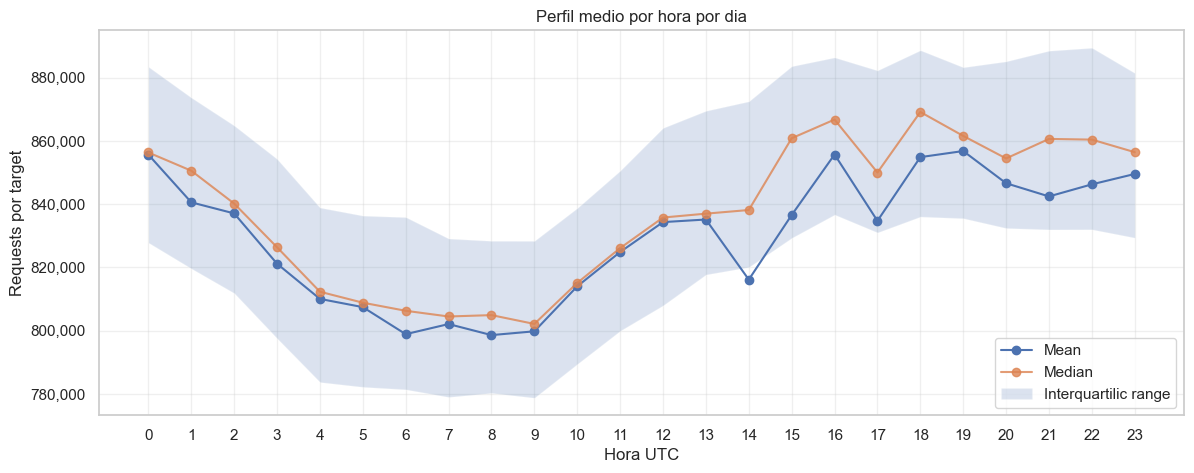

In [24]:
hourly_profile = eda.groupby("hour")["requests_per_target"].agg(
    mean="mean",
    median="median",
    p25=lambda values: values.quantile(0.25),
    p75=lambda values: values.quantile(0.75),
    min="min",
    max="max",
).round(2)

display(hourly_profile)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hourly_profile.index, hourly_profile["mean"], marker="o", label="Mean")
ax.plot(hourly_profile.index, hourly_profile["median"], marker="o", label="Median", alpha=0.8)
ax.fill_between(
    hourly_profile.index.to_numpy(),
    hourly_profile["p25"].to_numpy(),
    hourly_profile["p75"].to_numpy(),
    alpha=0.2,
    label="Interquartilic range",
)
ax.set_title("Perfil medio por hora por dia")
ax.set_xlabel("Hora UTC")
ax.set_ylabel("Requests por target")
format_count_axis(ax)
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

#### Patrón por día de la semana

Ahora comparamos días hábiles y fines de semana. Para datos de tráfico, esta diferencia suele ser clave.

,mean,median,min,max,count
day_name,,,,,
Lunes,"829,697.36","829,076.00","608,418.25","909,128.50",119
Martes,"817,286.63","826,791.25","550,097.83","901,980.00",96
Miércoles,"832,847.63","837,612.75","647,085.30","913,841.00",96
Jueves,"826,008.23","835,455.50","526,169.37","924,146.50",96
Viernes,"812,213.28","837,220.00","318,307.50","919,332.50",96
Sábado,"853,701.65","853,428.00","788,625.00","921,038.50",97
Domingo,"836,154.82","838,367.25","601,571.33","913,271.00",120


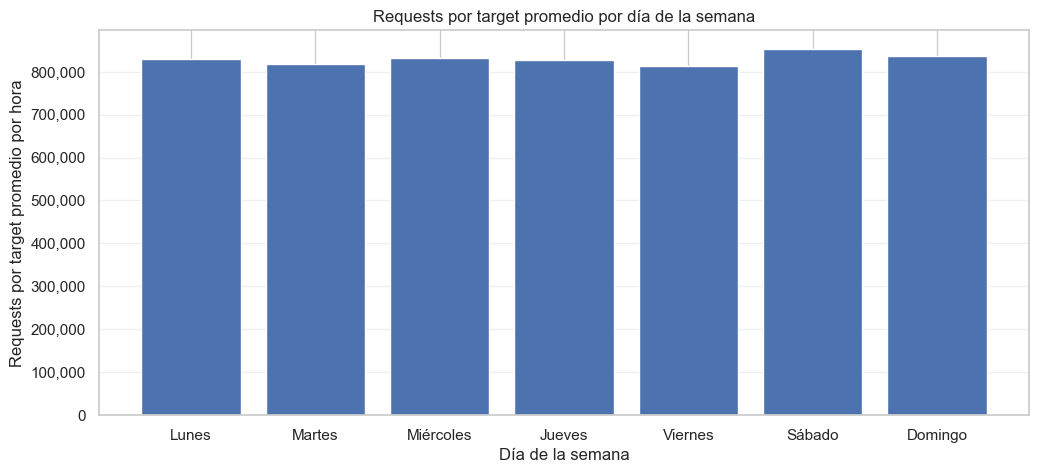

In [25]:
weekday_profile = eda.groupby("day_name", observed=True)["requests_per_target"].agg(
    mean="mean",
    median="median",
    min="min",
    max="max",
    count="count",
).round(2)

display(weekday_profile)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(weekday_profile.index.astype(str), weekday_profile["mean"])
ax.set_title("Requests por target promedio por día de la semana")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Requests por target promedio por hora")
format_count_axis(ax)
ax.grid(True, axis="y", alpha=0.3)
plt.show()

#### Mapa de calor día/hora

El mapa de calor permite ver rápidamente si la carga se concentra en ciertas horas y si ese patrón cambia a lo largo del período observado.

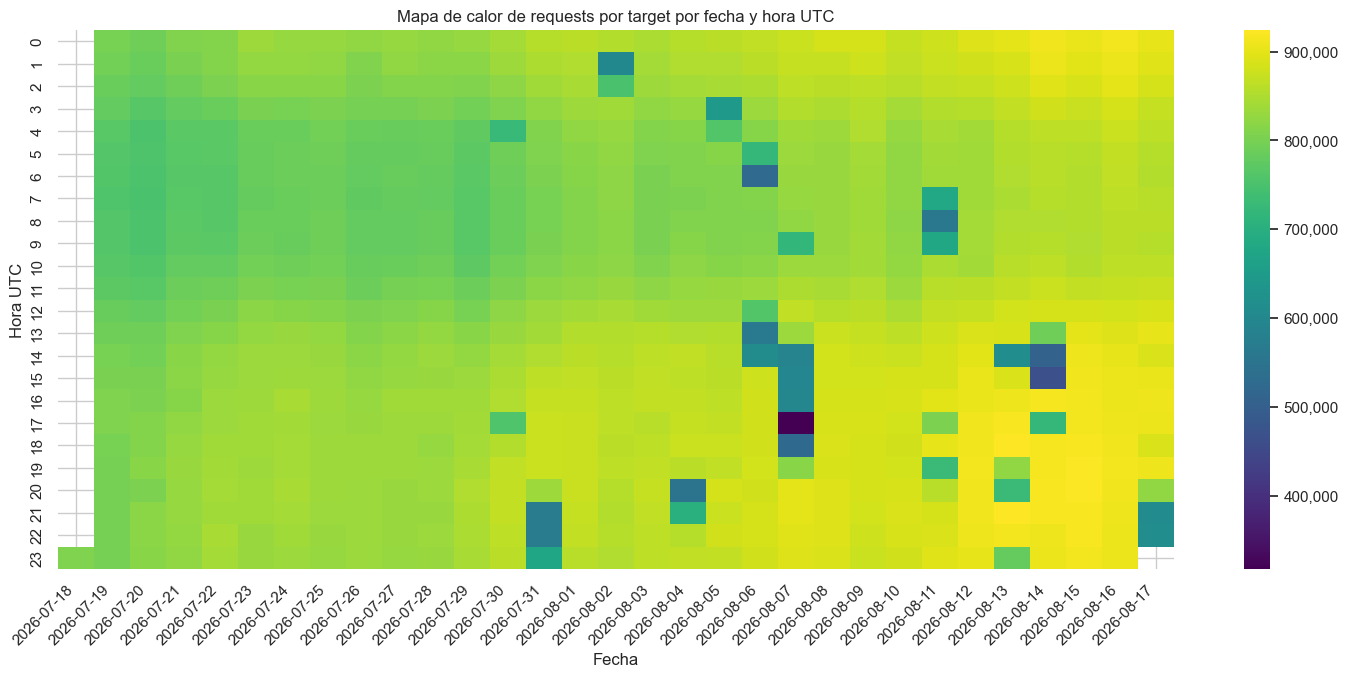

In [26]:
heatmap_data = eda.pivot_table(index="hour", columns="date", values="requests_per_target", aggfunc="mean")

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(heatmap_data, cmap="viridis", ax=ax, cbar_kws={"format": mtick.StrMethodFormatter("{x:,.0f}")})
ax.set_title("Mapa de calor de requests por target por fecha y hora UTC")
ax.set_xlabel("Fecha")
ax.set_ylabel("Hora UTC")
plt.xticks(rotation=45, ha="right")
plt.show()

#### Ventanas móviles

Una media móvil de 24 horas resume el nivel diario subyacente. El desvío móvil de 24 horas ayuda a detectar cambios de variabilidad.

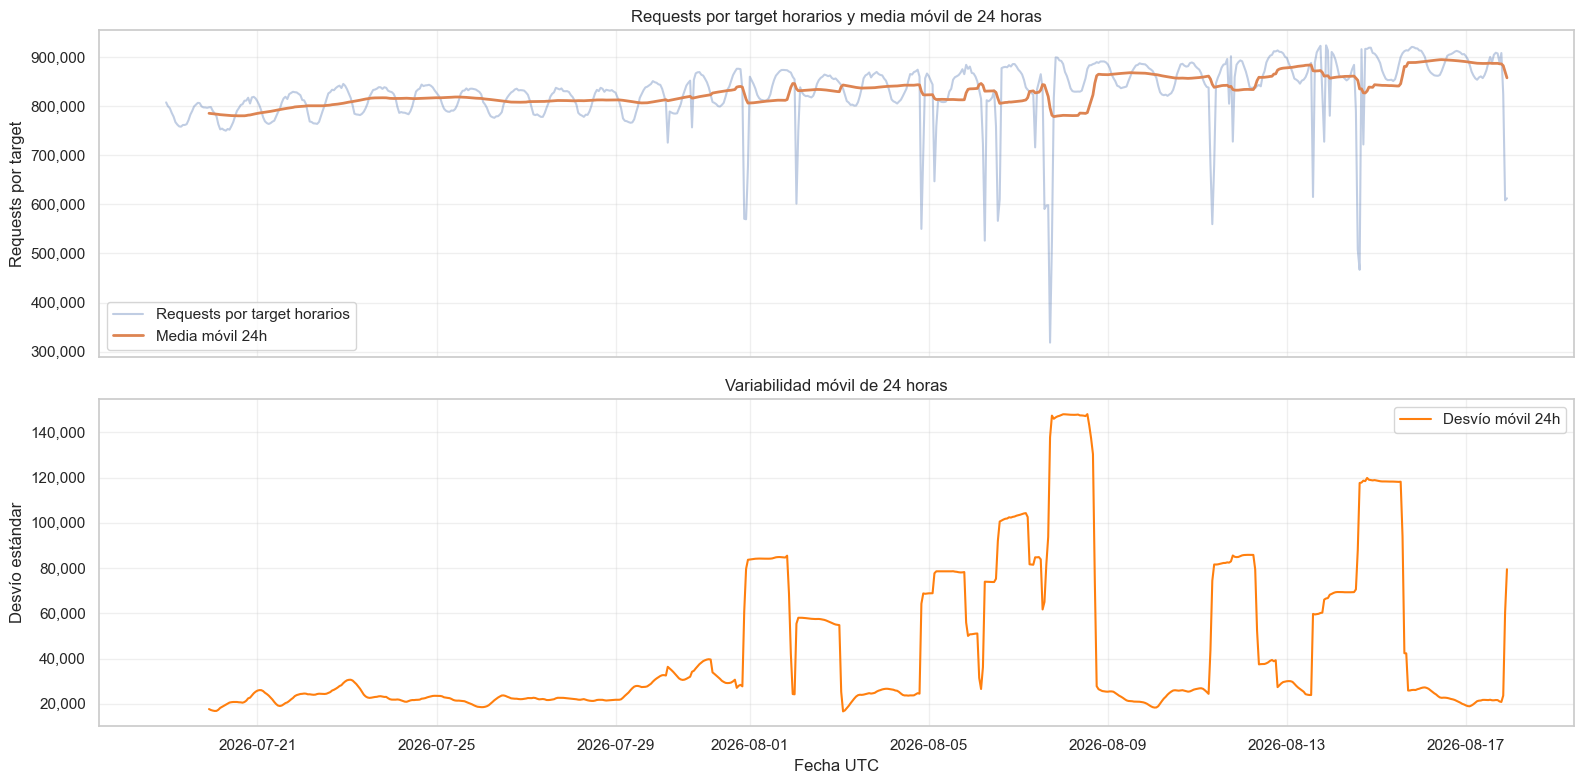

In [27]:
rolling_window = 24
rolling_mean = eda["requests_per_target"].rolling(rolling_window).mean()
rolling_std = eda["requests_per_target"].rolling(rolling_window).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(eda.index, eda["requests_per_target"], alpha=0.35, label="Requests por target horarios")
axes[0].plot(rolling_mean.index, rolling_mean, linewidth=2, label="Media móvil 24h")
axes[0].set_title("Requests por target horarios y media móvil de 24 horas")
axes[0].set_ylabel("Requests por target")
format_count_axis(axes[0])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rolling_std.index, rolling_std, color="tab:orange", label="Desvío móvil 24h")
axes[1].set_title("Variabilidad móvil de 24 horas")
axes[1].set_xlabel("Fecha UTC")
axes[1].set_ylabel("Desvío estándar")
format_count_axis(axes[1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Valores atípicos simples por IQR

Como primer criterio exploratorio, usamos el rango intercuartílico. Esto no define incidentes por sí solo; solamente marca horas que merecen inspección.

In [28]:
q1 = eda["requests_per_target"].quantile(0.25)
q3 = eda["requests_per_target"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = eda[(eda["requests_per_target"] < lower_bound) | (eda["requests_per_target"] > upper_bound)].copy()
outliers["outlier_type"] = np.where(outliers["requests_per_target"] < lower_bound, "bajo", "alto")

print(f"Límite inferior: {lower_bound:,.2f}")
print(f"Límite superior: {upper_bound:,.2f}")
print(f"Cantidad de horas marcadas como atípicas: {len(outliers)}")

display(
    outliers[["requests_per_target", "day_name", "hour", "is_weekend", "outlier_type"]]
    .sort_values("requests_per_target")
    .head(20)
)

Límite inferior: 713,516.75
Límite superior: 959,141.75
Cantidad de horas marcadas como atípicas: 23


,requests_per_target,day_name,hour,is_weekend,outlier_type
period_start_utc,,,,,
2026-08-07 17:00:00+00:00,"318,307.50",Viernes,17,False,bajo
2026-08-14 15:00:00+00:00,"466,707.17",Viernes,15,False,bajo
2026-08-14 14:00:00+00:00,"507,551.44",Viernes,14,False,bajo
2026-08-07 18:00:00+00:00,"523,253.43",Viernes,18,False,bajo
2026-08-06 06:00:00+00:00,"526,169.37",Jueves,6,False,bajo
2026-08-04 20:00:00+00:00,"550,097.83",Martes,20,False,bajo
2026-08-11 08:00:00+00:00,"559,727.00",Martes,8,False,bajo
2026-08-06 13:00:00+00:00,"566,462.33",Jueves,13,False,bajo
2026-07-31 22:00:00+00:00,"569,677.67",Viernes,22,False,bajo


#### Autocorrelación

La ACF nos ayuda a ver dependencia temporal. En una serie horaria, picos alrededor de 24, 48 y 72 lags pueden sugerir estacionalidad diaria.

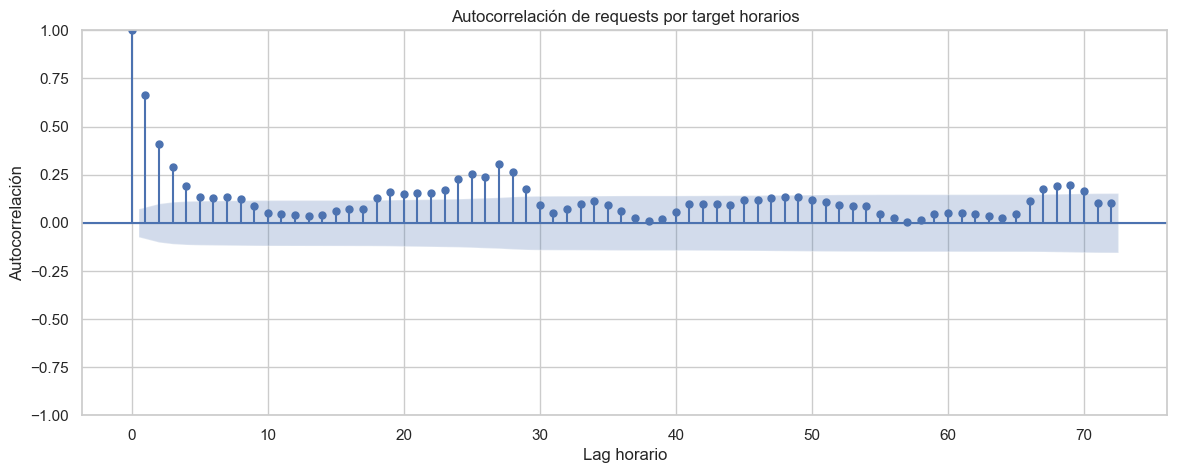

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(eda["requests_per_target"], lags=72, ax=ax)
ax.set_title("Autocorrelación de requests por target horarios")
ax.set_xlabel("Lag horario")
ax.set_ylabel("Autocorrelación")
plt.show()

#### Descomposición estacional

Probamos una descomposición aditiva con período 24 para separar tendencia, estacionalidad diaria y residuo.

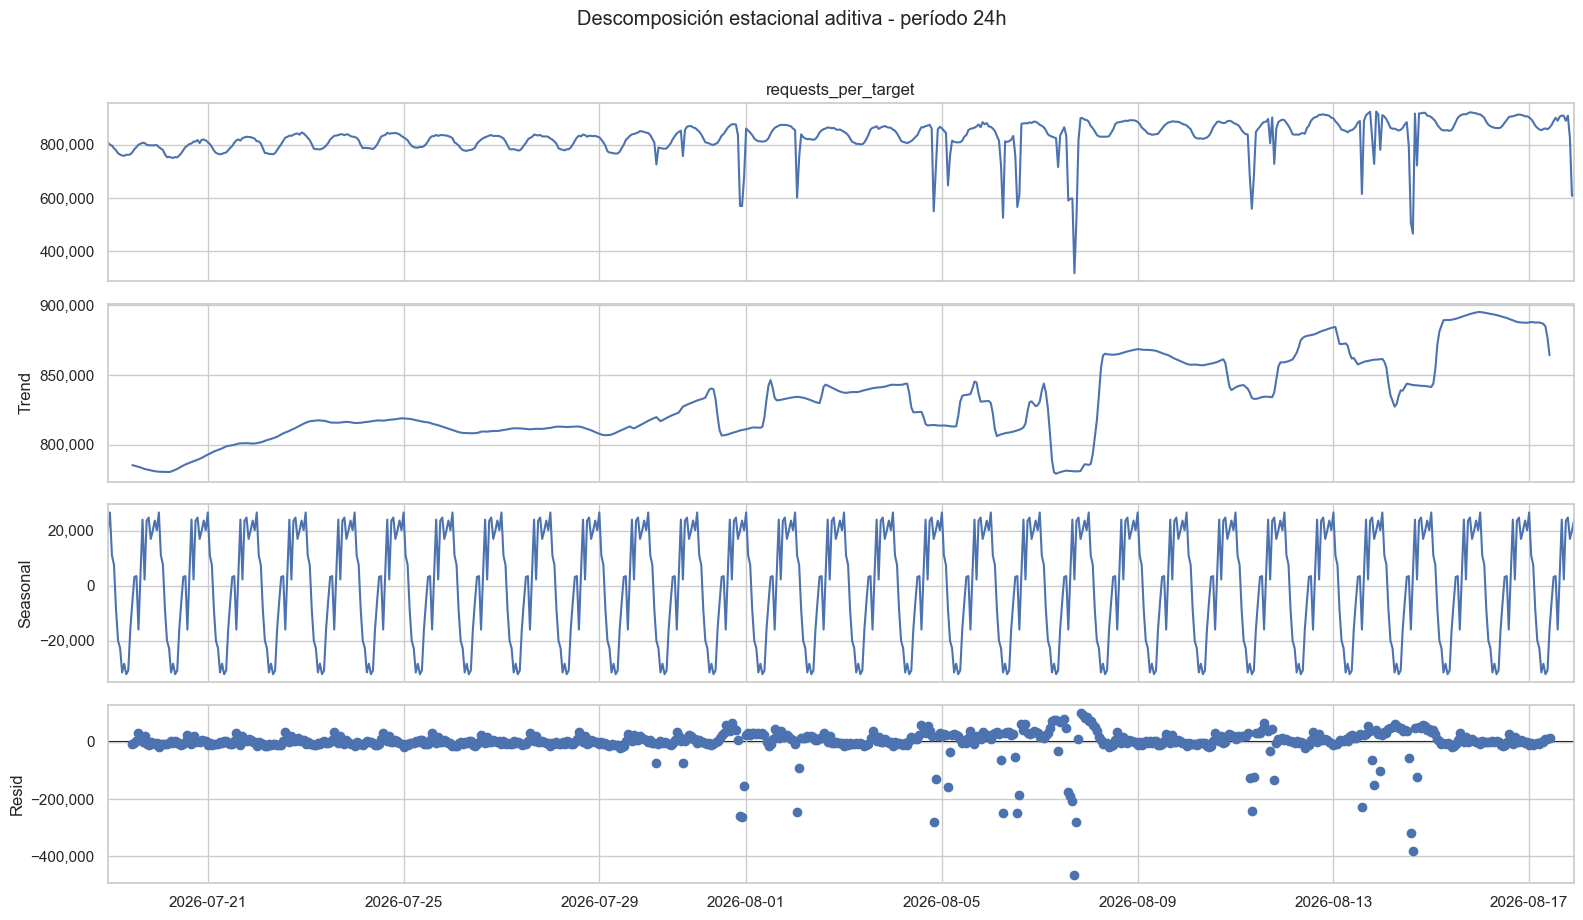

In [30]:
decomposition = seasonal_decompose(eda["requests_per_target"].asfreq("h"), model="additive", period=24)

fig = decomposition.plot()
fig.set_size_inches(16, 9)
for axis in fig.axes:
    format_count_axis(axis)
fig.suptitle("Descomposición estacional aditiva - período 24h", y=1.02)
plt.tight_layout()
plt.show()

#### Resumen automático de hallazgos

Esta celda calcula algunos puntos concretos para guiar las conclusiones. No reemplaza la interpretación visual: la complementa.

In [31]:
peak_hour = int(hourly_profile["mean"].idxmax())
low_hour = int(hourly_profile["mean"].idxmin())
max_ts = eda["requests_per_target"].idxmax()
min_ts = eda["requests_per_target"].idxmin()
weekend_summary = eda.groupby("is_weekend")["requests_per_target"].mean().rename(index={False: "hábil", True: "fin_de_semana"})

print(f"Hora promedio de mayor tráfico: {peak_hour}:00 UTC")
print(f"Hora promedio de menor tráfico: {low_hour}:00 UTC")
print(f"Máximo observado: {eda.loc[max_ts, 'requests_per_target']:,.2f} requests por target en {max_ts}")
print(f"Mínimo observado: {eda.loc[min_ts, 'requests_per_target']:,.2f} requests por target en {min_ts}")
print("\nPromedio por tipo de día:")
display(weekend_summary.to_frame("requests_per_target_promedio"))

Hora promedio de mayor tráfico: 19:00 UTC
Hora promedio de menor tráfico: 8:00 UTC
Máximo observado: 924,146.50 requests por target en 2026-08-13 21:00:00+00:00
Mínimo observado: 318,307.50 requests por target en 2026-08-07 17:00:00+00:00

Promedio por tipo de día:


,requests_per_target_promedio
is_weekend,
hábil,"823,888.95"
fin_de_semana,"843,998.34"


#### Conclusiones para discutir

A partir del análisis anterior, responder:

- ¿La serie presenta un patrón diario claro?
- ¿Los fines de semana se comportan distinto a los días hábiles?
- ¿La media móvil sugiere cambios de nivel dentro del período observado?
- ¿La variabilidad parece estable o cambia en ciertos períodos?
- ¿La ACF muestra dependencia temporal relevante para un modelo futuro?
- ¿Qué horas marcadas como atípicas podrían ser ruido normal y cuáles deberían investigarse?
- ¿La normalización por target cambia cómo interpretar volumen total frente a carga promedio?

Próximo paso natural: si el objetivo fuera pronóstico, recién después de esta EDA tendría sentido evaluar transformaciones, partición temporal train/test y modelos base.